# YOLO Detection Example

## YOLO Object Detection

This notebook is an example of object detection with **Ultralytics YOLO**.

```
Image (URL or file) → YOLO detector → Annotated image + bounding boxes + confidence scores
```

Unlike classification (one label per image), detection **locates multiple objects** within an image and draws a bounding box around each one.

### Available models

| Model | Params | Speed |
|-------|--------|-------|
| `yolo11x.pt` | 56.9 M | slowest / most accurate |
| `yolo11l.pt` | 25.3 M | — |
| `yolo11m.pt` | 20.1 M | — |
| `yolo11s.pt` |  9.4 M | — |
| `yolo11n.pt` |  2.6 M | fastest / lightest |

Change `MODEL_NAME` in the writefile cell to switch between them.

📄 [Ultralytics YOLO docs](https://docs.ultralytics.com/)

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/CV-Samples/yolo"
!mkdir -p "{PROJECT_PATH}"
%cd "{PROJECT_PATH}"
!ls

Mounted at /content/drive
/content/drive/MyDrive/CV-Samples/yolo


In [3]:
# Download sample images from GitHub
import os

# Image files to download
IMAGE_FILES = [
    'teefarm-pile-1651945_640.jpg',
]

BASE_URL = 'https://raw.githubusercontent.com/mastnk/cv-samples/main/yolo'
for fname in IMAGE_FILES:
    url = f'{BASE_URL}/{fname}'
    dest = f'{PROJECT_PATH}/{fname}'
    if not os.path.exists(dest):
        os.system(f'wget -q "{url}" -O "{dest}"')
        print(f'Downloaded: {fname}')
    else:
        print(f'Already exists: {fname}')

%cd "{PROJECT_PATH}"
!ls


Downloaded: teefarm-pile-1651945_640.jpg
/content/drive/MyDrive/CV-Samples/yolo
teefarm-pile-1651945_640.jpg


In [2]:
# Install Ultralytics
!pip install ultralytics -q

import ultralytics
ultralytics.checks()  # check environment

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.5/107.7 GB disk)


## Using Your Own Images

There are two ways to provide images for detection:

**① Specify a URL**  
Pass a direct image URL to the `--url` flag when running the script:
```
%run detection.py --url https://example.com/image.jpg
```

**② Upload images to the `images/` folder**  
Place your image files in `PROJECT_PATH/`, then run the script with `--file` or `--dir`.

The easiest way to upload is through **Google Drive**:  
Open [drive.google.com](https://drive.google.com), navigate to `My Drive / CV-Samples / yolo/`, and drag & drop your files there.  
They will be immediately available in Colab via the mounted drive — no extra upload step needed.

```
%run detection.py --file your_image.jpg   # single file
%run detection.py --dir  .                       # all images in folder
```

## Selecting a Model

In the writefile cell below, change `MODEL_NAME` to switch models.  
When multiple `MODEL_NAME = ...` lines are listed, **only the last one takes effect**.

```python
# MODEL_NAME = 'yolo11x.pt'  # 56.9M params — most accurate, slowest
# MODEL_NAME = 'yolo11l.pt'  # 25.3M params
# MODEL_NAME = 'yolo11m.pt'  # 20.1M params
# MODEL_NAME = 'yolo11s.pt'  #  9.4M params
MODEL_NAME   = 'yolo11n.pt'  #  2.6M params — fastest, lightest  ← active
```

Larger models are more accurate but take longer to run. Start with `yolo11n.pt` for quick experiments.

In [4]:
# Save this cell as a Python file (Execute after editing)
%%writefile detection.py
"""YOLO Object Detection — command-line interface.

Usage:
  %run detection.py --url  <image_url>  [--disp] [--conf FLOAT]
  %run detection.py --file <image_path> [--disp] [--conf FLOAT]
  %run detection.py --dir  <image_dir>  [--disp] [--conf FLOAT]
"""

import argparse
import glob
import os

from ultralytics import YOLO
from PIL import Image
import requests
from io import BytesIO

# ---- IPython display (works when executed via %run in Colab) -----
try:
    from IPython.display import display as ipy_display
    _has_ipy = True
except ImportError:
    _has_ipy = False

# ---- Configuration -----------------------------------------------
MODEL_NAME   = 'yolo11n.pt'  #  2.6M params — fastest / lightest
# MODEL_NAME = 'yolo11s.pt'  #  9.4M params
# MODEL_NAME = 'yolo11m.pt'  # 20.1M params
# MODEL_NAME = 'yolo11l.pt'  # 25.3M params
# MODEL_NAME = 'yolo11x.pt'  # 56.9M params — most accurate

PROJECT_PATH = '/content/drive/MyDrive/CV-Samples/yolo'

# ---- Model loading -----------------------------------------------
model = YOLO(MODEL_NAME)

# ---- Display helper ----------------------------------------------
def show(annotated, label: str, disp: bool) -> None:
    """When --disp is active, display the annotated image then print the filename/URL."""
    if disp:
        if _has_ipy:
            ipy_display(annotated)
        print(label)

# ---- Functions ---------------------------------------------------
def detect_url(url: str, conf: float = 0.25, disp: bool = False):
    """Download an image from a URL and detect objects."""
    image     = Image.open(BytesIO(requests.get(url).content)).convert('RGB')
    results   = model.predict(image, conf=conf, verbose=False)
    annotated = Image.fromarray(results[0].plot()[:, :, ::-1])  # BGR -> RGB
    show(annotated, url, disp)
    boxes = results[0].boxes
    names = results[0].names
    for box in boxes:
        cls_id   = int(box.cls[0])
        conf_val = float(box.conf[0])
        print(f'  {names[cls_id]:<20} {conf_val*100:.1f}%')
    return results


def detect_file(path: str, conf: float = 0.25, disp: bool = False):
    """Detect objects in a single local image file."""
    image     = Image.open(path).convert('RGB')
    results   = model.predict(image, conf=conf, verbose=False)
    annotated = Image.fromarray(results[0].plot()[:, :, ::-1])  # BGR -> RGB
    show(annotated, path, disp)
    boxes = results[0].boxes
    names = results[0].names
    for box in boxes:
        cls_id   = int(box.cls[0])
        conf_val = float(box.conf[0])
        print(f'  {names[cls_id]:<20} {conf_val*100:.1f}%')
    return results


def detect_dir(directory: str, conf: float = 0.25, disp: bool = False):
    """Detect objects in all images in a directory."""
    exts = ['jpg', 'jpeg', 'png', 'bmp', 'JPG', 'JPEG', 'PNG', 'BMP']
    filepaths = []
    for ext in exts:
        filepaths += sorted(glob.glob(os.path.join(directory, f'*.{ext}')))

    if not filepaths:
        print(f'No images found in: {directory}')
        return

    for path in filepaths:
        detect_file(path, conf, disp)
        print()


# ---- Argument parsing --------------------------------------------
parser = argparse.ArgumentParser(description='YOLO Object Detection')
group  = parser.add_mutually_exclusive_group(required=True)
group.add_argument('--url',  type=str,              help='Image URL to detect')
group.add_argument('--file', type=str,              help='Path to a single image file')
group.add_argument('--dir',  type=str,              help='Directory of images to detect')
parser.add_argument('--conf', type=float, default=0.25, help='Confidence threshold (default: 0.25)')
parser.add_argument('--disp', action='store_true',      help='Display annotated image and filename/URL before results')
args = parser.parse_args()

# ---- Run ---------------------------------------------------------
if args.url:
    detect_url(args.url,   conf=args.conf, disp=args.disp)
elif args.file:
    detect_file(args.file, conf=args.conf, disp=args.disp)
elif args.dir:
    detect_dir(args.dir,   conf=args.conf, disp=args.disp)


Writing detection.py


## `detection.py` Usage

After running the `%%writefile` cell above, `detection.py` is saved in `PROJECT_PATH`.
Run it with **`%run`** (not `!python`) so that inline image display works in Colab.

```
%run detection.py --url  <image_url>        # detect objects in a remote image
%run detection.py --file <image_path>       # detect objects in a single local file
%run detection.py --dir  <image_directory>  # detect objects in all images in a folder
```

**Optional arguments**

| Flag | Default | Description |
|------|---------|-------------|
| `--disp` | off | Display annotated image and filename / URL before results |
| `--conf <f>` | `0.25` | Confidence threshold for detections (0.0 – 1.0) |

**Examples**

```bash
# Detect objects in a remote image and display it
%run detection.py --url https://cdn.pixabay.com/photo/2016/12/13/05/15/puppy-1903313_640.jpg --disp

# Detect objects in one file, lower confidence threshold
%run detection.py --file street.jpg --conf 0.1 --disp

# Detect objects in every image in the folder, display each one
%run detection.py --dir . --disp
```

**Output format (with `--disp`)**

```
<annotated image displayed inline>
street.jpg
  person               87.3%
  car                  91.5%
  bicycle              76.2%
```

## Execution Methods

Use **`%run`** to execute `detection.py` inside the Colab kernel — this enables inline image display with `--disp`.

| Mode | Flag | Description |
|------|------|-------------|
| From URL | `--url <url>` | Fetches and detects objects in a remote image |
| Single file | `--file <path>` | Detects objects in one local image |
| Directory | `--dir <path>` | Detects objects in all images in a folder |

Add `--disp` to display each annotated image and its filename / URL before the results.  
Add `--conf <f>` to change the confidence threshold (default: 0.25).

/content/drive/MyDrive/CV-Samples/yolo


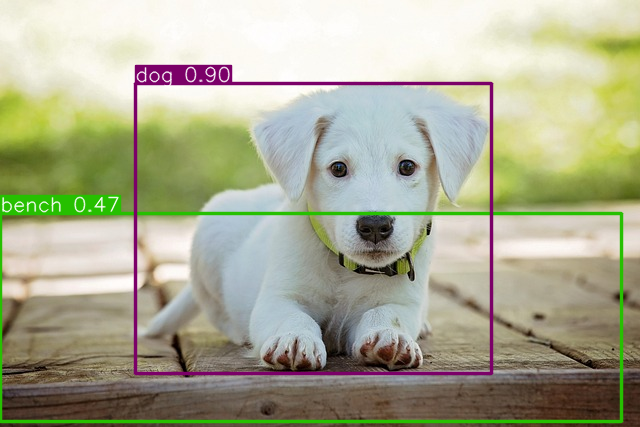

https://cdn.pixabay.com/photo/2016/12/13/05/15/puppy-1903313_640.jpg
  dog                  89.9%
  bench                47.3%


In [5]:
# Execute: detect objects in an image from URL (with display)
%cd "{PROJECT_PATH}"
%run detection.py --disp --url https://cdn.pixabay.com/photo/2016/12/13/05/15/puppy-1903313_640.jpg

/content/drive/MyDrive/CV-Samples/yolo


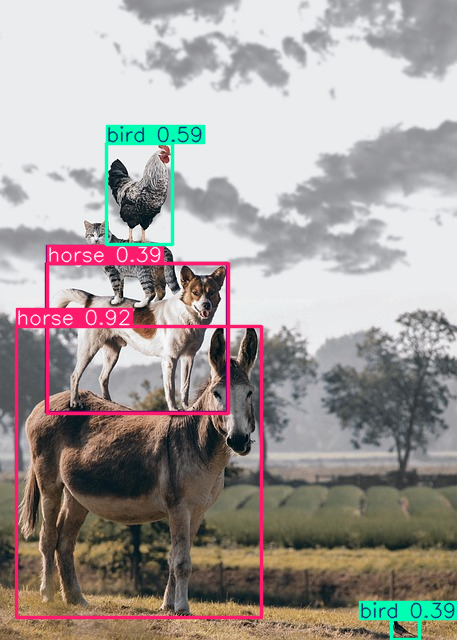

teefarm-pile-1651945_640.jpg
  horse                91.8%
  bird                 59.2%
  horse                39.0%
  bird                 38.7%
  dog                  33.9%


In [6]:
# Execute: detect objects in a single local image file (with display)
%cd "{PROJECT_PATH}"
%run detection.py --disp --file teefarm-pile-1651945_640.jpg

/content/drive/MyDrive/CV-Samples/yolo


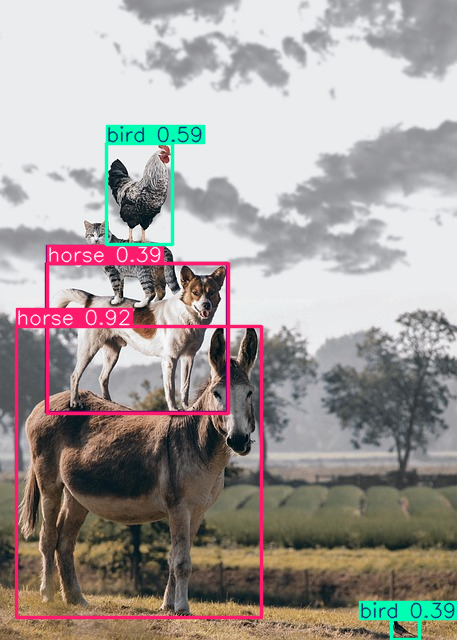

./teefarm-pile-1651945_640.jpg
  horse                91.8%
  bird                 59.2%
  horse                39.0%
  bird                 38.7%
  dog                  33.9%



In [7]:
# Execute: detect objects in all images in a directory (with display)
%cd "{PROJECT_PATH}"
%run detection.py --disp --dir .

💾 **Don't forget to save this notebook!**

To keep your work, go to **File → Save a copy in Drive** before closing.

